In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numba.cpython.randomimpl import ol_np_random_gamma1
from tqdm import tqdm
import torch
import wandb

In [ ]:
from inference_visualization import download_model_and_config, build_esn_from_config, generate_series_using_dataset, load_model, mask_and_predict

In [ ]:
# run_id = '8mrjpiu1'
run_id = '9z2vqcbx'

In [ ]:
api = wandb.Api()
run = api.run(f"mlm_esn/{run_id}")

config = run.config

In [9]:
# model_path, config = download_model_and_config(run_id)
config['esn_store_state'] = True
config['dataset']['val']['num_series'] = 20_000
# model = load_model(model_path, config)
# model.to('cuda')
model=None
dataloader = generate_series_using_dataset(config, num_series=1)

In [21]:
# Run multiple inferences to create more comprehensive PCA embedding
num_series = 100  # Number of series to generate for PCA
all_hidden_states = []
first_hidden_states = None
series_dataloader = generate_series_using_dataset(config, num_series=1)
data_iter = iter(series_dataloader)
for i in tqdm(range(num_series)):
    _ = next(iter(series_dataloader))
    hidden_states = np.hstack(series_dataloader.dataset.esn.hidden_states)
    if i == 1:
        first_hidden_states = hidden_states.copy()
    all_hidden_states.append(hidden_states)

combined_hidden_states = np.hstack(all_hidden_states)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined_hidden_states.T)
first_series_pca = pca.transform(first_hidden_states.T)
plt.figure(figsize=(10, 8))
plt.plot(first_series_pca[:, 0], first_series_pca[:, 1], '-',
         color='blue', alpha=0.5, linewidth=1, zorder=1)
plt.scatter(first_series_pca[:, 0], first_series_pca[:, 1],
           c=range(len(first_series_pca)), cmap='viridis',
           alpha=0.8, s=30, zorder=2)
plt.colorbar(label='Time step')
plt.title('PCA of ESN Hidden States (First Series) in Combined Embedding Space')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.tight_layout()
plt.show()

RuntimeError: CUDA error: unspecified launch failure
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [7]:
def mask_and_predict_all(model, x, dataloader):
    """
    Mask random tokens and predict using the model.

    Args:
        model: Transformer model
        x: Input tensor (batch_size, sequence_length, 1)
        masking_ratio: Ratio of tokens to mask

    Returns:
        x_original: Original input
        x_masked: Masked input with mask indicator channel
        x_pred: Model predictions
        masked_indices: Indices of masked tokens
    """
    # Make a copy of the input
    hidden_states = np.hstack(dataloader.dataset.esn.hidden_states).T
    input = dataloader.dataset.esn.input
    x_original = x.clone()
    predicted_series, emmbedings = [], []
    for i in range(x.shape[1]):
        seq_length = x.shape[1]
        masked_indices = np.array([i])
        x_masked = x_original.clone()
        x_masked[:, masked_indices, :] = 0
        mask_col = torch.zeros(x.shape[0], seq_length, 1, device=x.device)
        mask_col[:, masked_indices, :] = 1.0
        x_input = torch.cat([x_masked, mask_col], dim=2)
        # with torch.no_grad():
        #     pred, result = model.forward_with_embbeding(x_input)
        #     predicted_series.append(pred[0, i, 0].detach().cpu().numpy().item())
        #     emmbedings.append(result[0, i, :].detach().cpu().numpy())
    return predicted_series, emmbedings, x_original.detach().cpu().numpy().flatten(), hidden_states, np.vstack(input)

In [10]:
res = []
data = iter(dataloader)
for i in tqdm(range(1000)):
    x = next(data)[0].to('cuda')
    res.append(mask_and_predict_all(model, x, dataloader))

100%|██████████| 1000/1000 [00:38<00:00, 25.86it/s]


In [11]:
# emmbs = np.vstack([np.vstack(x[1]) for x in res])
hidden_states = np.vstack([x[3] for x in res])

In [14]:
hidden_states.shape

(100000, 100)

In [ ]:
emmbs.shape

In [ ]:
dataloader.dataset.esn.W_out[0].abs().argmin()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

i = 13
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    emmbs, hidden_states[:, i], test_size=0.2, random_state=42
)

# Train linear regression model
rl = LinearRegression()
rl.fit(X_train, y_train)

# Make predictions on test set
y_pred = rl.predict(X_test)
y_pred_train = rl.predict(X_train)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_pred_train)


print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}, R-squared Train Score: {r2_train:.4f}")

# Visualize actual vs predicted for a single dimension

plt.figure(figsize=(10, 6))
plt.scatter(y_test[:], y_pred[:], alpha=0.5)
plt.plot([y_test[:].min(), y_test[:].max()],
         [y_test[:].min(), y_test[:].max()],
         'r--', lw=2)
plt.xlabel('Actual Hidden State')
plt.ylabel('Predicted Hidden State')
plt.title('Linear Regression: Actual vs Predicted (First Dimension)')
plt.tight_layout()
plt.show()


In [ ]:
hidden_states.shape

In [ ]:
hidden_states

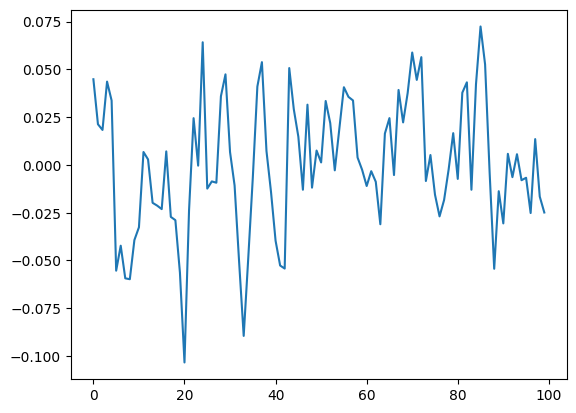

In [24]:
plt.plot(hidden_states[:100, 4])

In [ ]:
plt.plot(res[0])
plt.plot(res[2])

In [ ]:
res[1][0]

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Extract input values from res
input_values = np.vstack([x[4] for x in res])

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    emmbs, input_values, test_size=0.2, random_state=42
)

# Train linear regression model
rl = LinearRegression()
rl.fit(X_train, y_train)

# Make predictions on test set
y_pred = rl.predict(X_test)
y_pred_train = rl.predict(X_train)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_pred_train)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}, R-squared Train Score: {r2_train:.4f}")

# Visualize actual vs predicted for a single dimension
plt.figure(figsize=(10, 6))
plt.scatter(y_test[:, 0], y_pred[:, 0], alpha=0.5)
plt.plot([y_test[:, 0].min(), y_test[:, 0].max()],
         [y_test[:, 0].min(), y_test[:, 0].max()],
         'r--', lw=2)
plt.xlabel('Actual Input Value')
plt.ylabel('Predicted Input Value')
plt.title('Linear Regression: Embedding to Input Prediction (First Dimension)')
plt.tight_layout()
plt.show()